In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as wr
wr.filterwarnings('ignore')

In [29]:
df = pd.read_csv(r"..\data\raw\train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [30]:
df.shape

(891, 12)

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [32]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [33]:
df.columns.tolist()

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

In [34]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [35]:
df.duplicated().sum()

np.int64(0)

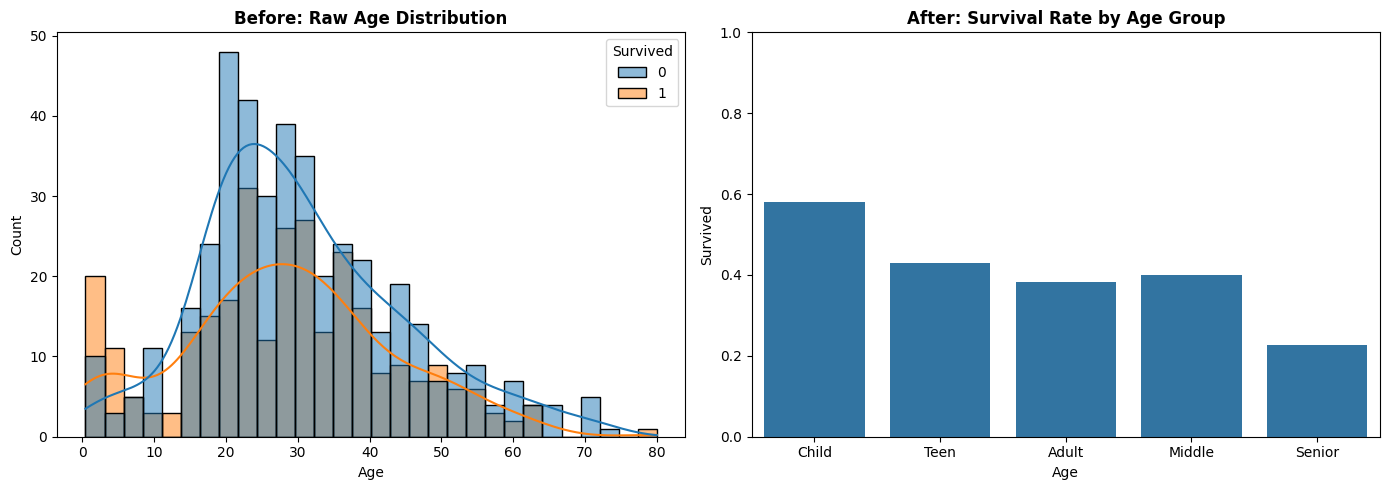

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before
sns.histplot(data=df, x='Age', hue='Survived', bins=30, kde=True, ax=axes[0])
axes[0].set_title('Before: Raw Age Distribution', fontweight='bold')

age_bins = pd.cut(
    df['Age'],
    bins=[0, 12, 18, 35, 60, 100],
    labels=['Child', 'Teen', 'Adult', 'Middle', 'Senior']
)

age_survival = df.groupby(age_bins)['Survived'].mean().reset_index()

# After
sns.barplot(data=age_survival, x='Age', y='Survived', ax=axes[1])
axes[1].set_title('After: Survival Rate by Age Group', fontweight='bold')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

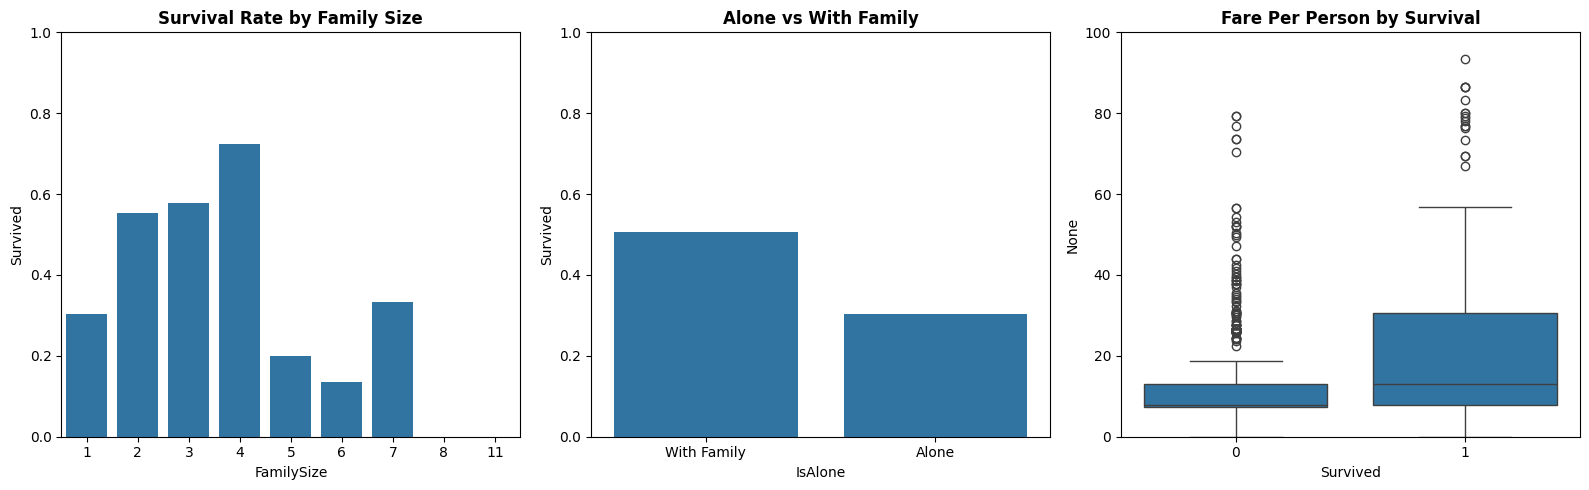

Interaction features reveal powerful patterns!
   Alone survival rate: 0.304
   With family survival rate: 0.506


In [38]:
# Features
family_size = df['SibSp'] + df['Parch'] + 1
is_alone = (family_size == 1).astype(int)
fare_per_person = df['Fare'] / family_size

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Family Size vs Survival
fam_survival = df.groupby(family_size)['Survived'].mean().reset_index()
fam_survival.columns = ['FamilySize', 'Survived']

sns.barplot(data=fam_survival, x='FamilySize', y='Survived', ax=axes[0])
axes[0].set_title('Survival Rate by Family Size', fontweight='bold')
axes[0].set_ylim(0, 1)

# Alone vs Not Alone
alone_survival = df.groupby(is_alone)['Survived'].mean().reset_index()
alone_survival.columns = ['IsAlone', 'Survived']
alone_survival['IsAlone'] = alone_survival['IsAlone'].map({0: 'With Family', 1: 'Alone'})

sns.barplot(data=alone_survival, x='IsAlone', y='Survived', ax=axes[1])
axes[1].set_title('Alone vs With Family', fontweight='bold')
axes[1].set_ylim(0, 1)

# Fare per person distribution
sns.boxplot(x=df['Survived'], y=fare_per_person, ax=axes[2])
axes[2].set_title('Fare Per Person by Survival', fontweight='bold')
axes[2].set_ylim(0, 100)

plt.tight_layout()
plt.show()

print("Interaction features reveal powerful patterns!")
print(f"   Alone survival rate: {df[is_alone==1]['Survived'].mean():.3f}")
print(f"   With family survival rate: {df[is_alone==0]['Survived'].mean():.3f}")

In [43]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

In [46]:
df['Initial'] = df['Name'].str.extract(r'([A-Za-z]+)\.')
df['Initial'] = df['Initial'].replace(
    ['Mlle','Mme','Ms','Dr','Major','Lady','Countess','Jonkheer','Col','Rev','Capt','Sir','Don'],
    ['Miss','Miss','Miss','Mr','Mr','Mrs','Mrs','Other','Other','Other','Mr','Mr','Mr']
)

pd.crosstab(df['Initial'], df['Sex']).T

Initial,Master,Miss,Mr,Mrs,Other
Sex,,,,,
0,40,0,528,0,9
1,0,186,1,127,0


In [47]:
age_mean = df.groupby('Initial')['Age'].mean()
df['Age'] = df['Age'].fillna(df['Initial'].map(age_mean))

In [48]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Initial
0,1,0,3,"Braund, Mr. Owen Harris",0,22.00,1,0,A/5 21171,7.2500,NaN,0.0,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.00,1,0,PC 17599,71.2833,C85,1.0,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",1,26.00,0,0,STON/O2. 3101282,7.9250,NaN,0.0,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.00,1,0,113803,53.1000,C123,0.0,Mrs
4,5,0,3,"Allen, Mr. William Henry",0,35.00,0,0,373450,8.0500,NaN,0.0,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",0,27.00,0,0,211536,13.0000,NaN,0.0,Other
887,888,1,1,"Graham, Miss. Margaret Edith",1,19.00,0,0,112053,30.0000,B42,0.0,Miss
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,21.86,1,2,W./C. 6607,23.4500,NaN,0.0,Miss
889,890,1,1,"Behr, Mr. Karl Howell",0,26.00,0,0,111369,30.0000,C148,1.0,Mr


In [49]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
Initial          0
dtype: int64

In [50]:
df.drop('Cabin', axis=1, inplace=True)
df = df[df['Embarked'].notna()]
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Initial        0
dtype: int64

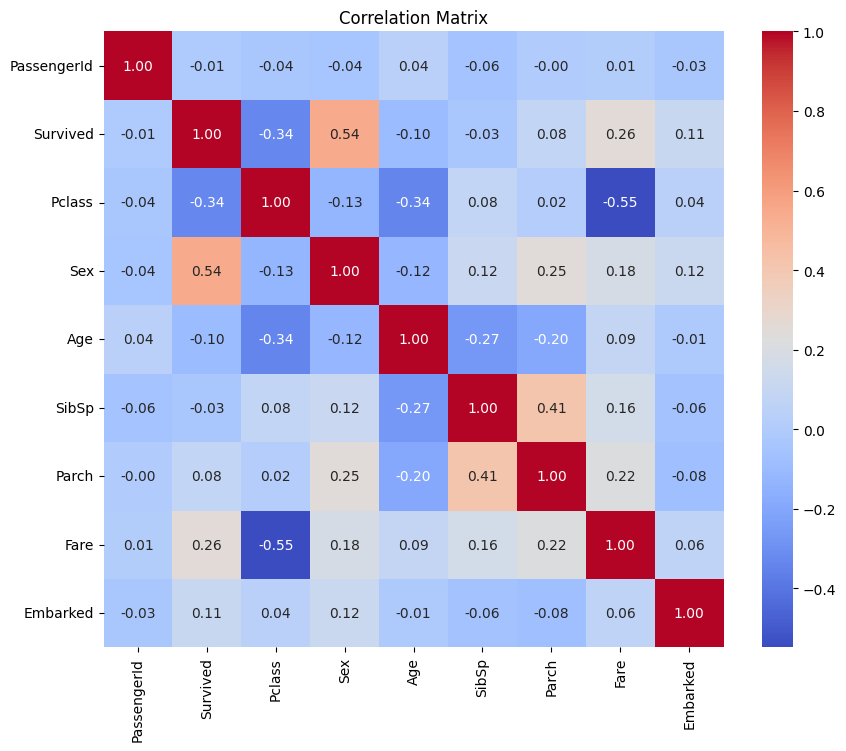

In [52]:
numeric_df = df.select_dtypes(include=['number'])
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()